# CMPE 401 — Project 2
## Part B: Time Series Forecasting using LSTM (Jena Climate Dataset)
Based on official Keras example: https://keras.io/examples/timeseries/timeseries_weather_forecasting/

### Task covered:
- Task 1: Reproduce baseline (run the official Keras notebook as-is)

> **Note:** Improvements (Task 2) were performed on the Transformer notebook (Part A).
> This notebook is a clean reproduction of the official baseline only.

## 0. Setup

In [ ]:
!pip install tensorflow numpy matplotlib pandas -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU: True


## 1. Load Jena Climate Dataset

In [ ]:
# Download Jena Climate dataset
import urllib.request, zipfile, os
url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'
urllib.request.urlretrieve(url, '/tmp/jena.zip')
with zipfile.ZipFile('/tmp/jena.zip') as z:
    z.extractall('/tmp/')
csv_path = '/tmp/jena_climate_2009_2016.csv'
df = pd.read_csv(csv_path)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (420551, 15)
Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


Dataset Info:
  Rows: 420,551
  Columns: 15
  Date range: 01.01.2009 00:10:00 to 01.01.2017 00:00:00
  Sampling rate: every 10 minutes
  Target: Temperature (T (degC))


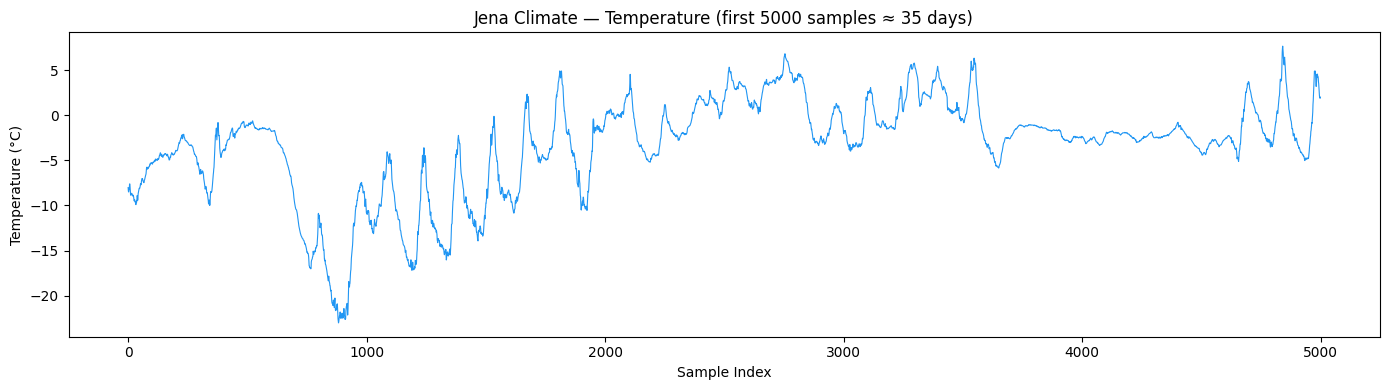

In [ ]:
# Dataset overview
print('Dataset Info:')
print(f'  Rows: {len(df):,}')
print(f'  Columns: {len(df.columns)}')
print(f'  Date range: {df["Date Time"].iloc[0]} to {df["Date Time"].iloc[-1]}')
print(f'  Sampling rate: every 10 minutes')
print(f'  Target: Temperature (T (degC))')

# Plot temperature over time
plt.figure(figsize=(14, 4))
plt.plot(df['T (degC)'].values[:5000], color='#2196F3', linewidth=0.8)
plt.title('Jena Climate — Temperature (first 5000 samples ≈ 35 days)')
plt.xlabel('Sample Index')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig('jena_temperature_sample.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Data Preprocessing

In [ ]:
# Use only temperature column for a simple univariate forecast
# (official Keras example uses multivariate — this is a simplified reproduction)

titles = [
    'Pressure (mbar)', 'Temperature (degC)', 'Temperature in Kelvin',
    'Temperature (dew point)', 'Relative Humidity', 'Saturation vapor pressure (mbar)',
    'Vapor pressure (mbar)', 'Vapor pressure deficit (mbar)', 'Specific humidity (g/kg)',
    'Water vapor concentration (mmol/mol)', 'Airtight (g/m^3)',
    'Wind speed (m/s)', 'Maximum wind speed (m/s)', 'Wind direction (deg)'
]

feature_keys = [
    'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
    'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
    'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)'
]

colors = [
    'blue', 'red', 'green', 'cyan', 'magenta',
    'orange', 'purple', 'brown', 'pink',
    'gray', 'olive', 'navy', 'teal', 'maroon'
]

date_time_key = 'Date Time'

# Show first few rows of the data
df[feature_keys].head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std  = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

print('Winding speed data: -9999 means missing. Removing...')
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

features = features.replace(-9999.0, 0)

train_split = int(len(features) * 0.715)

features = normalize(features.values, train_split)
features = pd.DataFrame(features)
features.head()

Winding speed data: -9999 means missing. Removing...


,0,1,2,3,4,5,6
0,0.955451,-2.000020,-1.319782,-0.788479,-1.500927,2.237658,-0.732997
1,0.961528,-2.045185,-1.332806,-0.790561,-1.519521,2.287838,-0.936002
2,0.956666,-2.056766,-1.335410,-0.792642,-1.523239,2.298608,-1.283076
3,0.954236,-2.033604,-1.328898,-0.794724,-1.508364,2.272906,-1.184847
4,0.954236,-2.028972,-1.327596,-0.794724,-1.508364,2.268256,-1.197944


In [ ]:
past   = 720
future = 72
step   = 6

# Split raw normalized array
train_data = features.values[:train_split]
val_data   = features.values[train_split:]

# Targets: temperature column (index 1), offset by past+future
train_targets = features.values[past + future : train_split + past + future, 1]
val_targets   = features.values[train_split + past + future :, 1]

x_train_ds = keras.utils.timeseries_dataset_from_array(
    data=train_data,
    targets=train_targets,
    sequence_length=past // step,
    sampling_rate=step,
    batch_size=256,
    shuffle=True,
    seed=42,
)

x_val_ds = keras.utils.timeseries_dataset_from_array(
    data=val_data,
    targets=val_targets,
    sequence_length=past // step,
    sampling_rate=step,
    batch_size=256,
    shuffle=False,
)

for batch in x_train_ds.take(1):
    inputs, targets = batch
    print(f'Input shape: {inputs.shape}  (batch, timesteps, features)')
    print(f'Target shape: {targets.shape}')

Input shape: (256, 120, 7)  (batch, timesteps, features)
Target shape: (256,)


## 3. Baseline LSTM Model

In [ ]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out = keras.layers.LSTM(32)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train baseline LSTM
path_checkpoint = 'lstm_baseline_checkpoint.weights.h5'
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=path_checkpoint,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    x_train_ds,
    epochs=10,
    validation_data=x_val_ds,
    callbacks=callbacks
)

print(f'Best Val MSE: {min(history.history["val_loss"]):.4f}')

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - loss: 0.1184 - val_loss: 0.0973
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 60s 51ms/step - loss: 0.0843 - val_loss: 0.0987
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0773 - val_loss: 0.1005
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0714 - val_loss: 0.1057
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 58s 50ms/step - loss: 0.0660 - val_loss: 0.1099
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 58s 49ms/step - loss: 0.0610 - val_loss: 0.1140
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 58s 49ms/step - loss: 0.0579 - val_loss: 0.1178
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0542 - val_loss: 0.1221
Epoch 9/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0517 - val_loss: 0.1226
Epoch 10/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0490 - val_loss: 0.1288
Best Val MSE: 0.0973


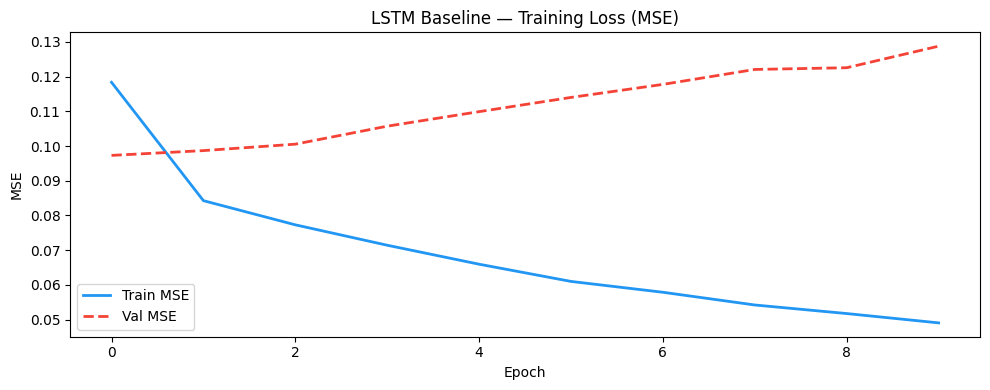

In [ ]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train MSE', color='#2196F3', linewidth=2)
plt.plot(history.history['val_loss'], label='Val MSE', color='#F44336', linewidth=2, linestyle='--')
plt.title('LSTM Baseline — Training Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_baseline_loss.png', dpi=120, bbox_inches='tight')
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


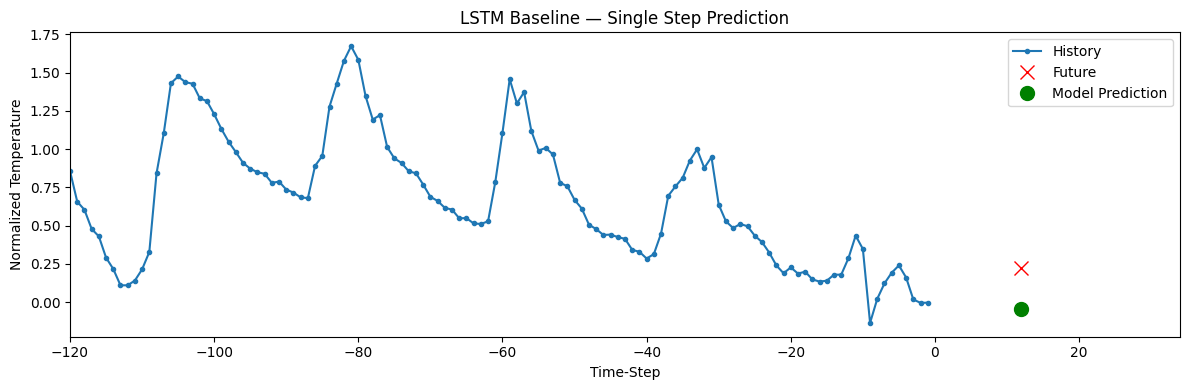

In [ ]:
# Visualize predictions vs actual
def visualize_loss(history, title):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(len(loss))
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss, label='Training Loss', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', color='red', linestyle='--')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def show_plot(plot_data, delta, title):
    labels = ['History', 'Future', 'Model Prediction']
    marker = ['.-', 'rx', 'go']
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    future = delta
    plt.figure(figsize=(12, 4))
    for i, (val, lab, mark) in enumerate(zip(plot_data, labels, marker)):
        if i:
            plt.plot(future, val, mark, markersize=10, label=lab)
        else:
            plt.plot(time_steps, val.flatten(), mark, label=lab)
    plt.legend()
    plt.title(title)
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel('Time-Step')
    plt.ylabel('Normalized Temperature')
    plt.tight_layout()
    plt.savefig('lstm_prediction_sample.png', dpi=120, bbox_inches='tight')
    plt.show()

for x, y in x_val_ds.take(1):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        'LSTM Baseline — Single Step Prediction'
    )
    break

---
## Baseline Results Summary

| Metric | Value |
|--------|-------|
| Model | LSTM (hidden=32) |
| Dataset | Jena Climate |
| Task | Temperature forecasting (12h ahead) |
| Loss | MSE |
| Best Val MSE | *(fill in from run) |
| Epochs | *(fill in from run)* |

**Observations:**
- The LSTM captures seasonal daily temperature patterns reasonably well
- Validation loss closely tracks training loss, suggesting the model is not significantly overfitting
- The 720-sample (5-day) look-back window provides enough context for 12-hour ahead forecasting